# Claude utilization vs. token usage

Checks, visually, whether Anthropic's reported `five_hour` / `seven_day`
utilization percentage is a **linear** function of token usage - and
whether raw token counts or dollar-cost-weighted tokens (the hypothesis
from [claudecodecamp.com](https://www.claudecodecamp.com/p/i-tried-to-reverse-engineer-claude-code-s-usage-limits),
tested against official pricing) track it more closely. See this
project's `README.md` for background and the "what is cache" explainer.

**Run `python3 ~/opt/claude-utilization-tracker/recompute_token_events.py`
before running this notebook**, so `token-events.jsonl` reflects
everything up to now (it's not kept incrementally - see the README).

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "/Users/jeanlescut/opt/claude-utilization-tracker/data"

# Toggle this to flip which axis is which in every plot below - a linear
# relationship stays linear either way, this is purely about which
# orientation is easier to eyeball.
SWAP_AXES = False

## Pricing model

Official per-model API pricing (`platform.claude.com/docs/en/about-claude/pricing`,
confirmed 2026-08-24) plus the uniform prompt-cache multipliers, applied
relative to each model's own input price. This is the "dollar_cost"
hypothesis being tested - see the README's cache explainer for what the
cache fields mean.

In [2]:
# $ / MTok, confirmed live from platform.claude.com/docs/en/about-claude/pricing
PRICING = {
    "claude-opus-5": {"in": 5, "out": 25},
    "claude-sonnet-5": {"in": 2, "out": 10},
    "claude-haiku-4-5-20251001": {"in": 1, "out": 5},
}
# Cache multipliers relative to a model's own base input price - uniform
# across models (same official pricing page).
CACHE_READ_MULT = 0.1
CACHE_WRITE_5M_MULT = 1.25
CACHE_WRITE_1H_MULT = 2.0


def dollar_cost(row):
    """Exact $ cost of one event, using the real 5m/1h cache-write split -
    None for a model not in PRICING (e.g. "<synthetic>" placeholder
    entries), which the plots below then simply skip."""
    price = PRICING.get(row["model"])
    if price is None:
        return None
    u = row["usage"]
    in_p, out_p = price["in"] / 1e6, price["out"] / 1e6
    cost = u.get("input_tokens", 0) * in_p + u.get("output_tokens", 0) * out_p
    cost += u.get("cache_read_input_tokens", 0) * in_p * CACHE_READ_MULT
    cc = u.get("cache_creation") or {}
    cost += cc.get("ephemeral_5m_input_tokens", 0) * in_p * CACHE_WRITE_5M_MULT
    cost += cc.get("ephemeral_1h_input_tokens", 0) * in_p * CACHE_WRITE_1H_MULT
    return cost


def raw_tokens(row):
    """Unweighted sum of every token field - input + output + cache
    creation + cache read, all counted equally regardless of type."""
    u = row["usage"]
    return (u.get("input_tokens", 0) + u.get("output_tokens", 0)
            + u.get("cache_read_input_tokens", 0) + u.get("cache_creation_input_tokens", 0))

## Load the two logs

In [3]:
def load_token_events(path):
    l_rows = []
    with open(path) as f:
        for line in f:
            e = json.loads(line)
            if not e.get("ts") or not e.get("model"):
                continue  # unparseable timestamp, or a non-usage entry
            l_rows.append({"ts": pd.Timestamp(e["ts"], unit="s", tz="UTC"),
                            "model": e["model"], "usage": e["usage"]})
    return pd.DataFrame(l_rows)


def load_util_log(path):
    """Rows before 2026-08-26 lack api_headers/have extra fields
    (token_deltas/baseline) - irrelevant here, since only the `api` block
    (same shape in every schema version) is used."""
    l_rows = []
    with open(path) as f:
        for line in f:
            r = json.loads(line)
            api = r.get("api")
            if not api:
                continue  # failed fetch that run - no reading to use
            row = {"ts": pd.Timestamp(r["ts"], unit="s", tz="UTC")}
            for key in ("five_hour", "seven_day"):
                b = api.get(key)
                row[f"{key}_pct"] = b["utilization"] if b else None
                row[f"{key}_resets_at"] = pd.Timestamp(b["resets_at"]) if b and b.get("resets_at") else pd.NaT
            l_rows.append(row)
    return pd.DataFrame(l_rows)


df_events = load_token_events(f"{DATA_DIR}/token-events.jsonl")
df_events["dollar_cost"] = df_events.apply(dollar_cost, axis=1)
df_events["raw_tokens"] = df_events.apply(raw_tokens, axis=1)

df_util = load_util_log(f"{DATA_DIR}/utilization-log.jsonl")

print(f"{len(df_events)} token events, {df_events['ts'].min()} to {df_events['ts'].max()}")
print(f"{len(df_util)} utilization readings, {df_util['ts'].min()} to {df_util['ts'].max()}")

14137 token events, 2026-07-30 13:38:59+00:00 to 2026-08-26 09:48:13+00:00
252 utilization readings, 2026-08-24 15:59:02+00:00 to 2026-08-26 09:40:07+00:00


## Detect reset windows

`resets_at` is a fixed boundary set when a window is created (not a
continuously-rolling "+5h from now") - consecutive readings that report
the *same* `resets_at` all belong to one window. Grouping (clustering)
those readings finds each window's boundary; a window's `start` is
inferred as the previous window's `end` (or `end - span` for the very
first one, since its true start predates this log).

The **last** window for each limit is very likely still open (its
`resets_at` is a future boundary Claude Code hasn't actually reached
yet) - its "peak so far" isn't a final number, unlike the earlier ones.

In [4]:
def detect_windows(df_util, key, span):
    s_resets = df_util[f"{key}_resets_at"].dropna().sort_values().unique()
    if len(s_resets) == 0:
        return []
    s_resets = pd.to_datetime(s_resets)
    clusters = [[s_resets[0]]]
    for t in s_resets[1:]:
        if (t - clusters[-1][-1]) < pd.Timedelta(minutes=5):
            clusters[-1].append(t)
        else:
            clusters.append([t])
    l_windows = []
    prev_end = None
    for i, c in enumerate(clusters):
        end = c[-1]
        start = prev_end if prev_end is not None else end - span
        peak = df_util.loc[df_util[f"{key}_resets_at"].isin(c), f"{key}_pct"].max()
        l_windows.append({"start": start, "end": end, "peak_pct": peak,
                           "is_open": i == len(clusters) - 1})
        prev_end = end
    return l_windows


fh_windows = detect_windows(df_util, "five_hour", pd.Timedelta(hours=5))
sd_windows = detect_windows(df_util, "seven_day", pd.Timedelta(days=7))
print(f"five_hour: {len(fh_windows)} windows ({sum(not w['is_open'] for w in fh_windows)} closed)")
print(f"seven_day: {len(sd_windows)} windows ({sum(not w['is_open'] for w in sd_windows)} closed)")

five_hour: 4 windows (3 closed)
seven_day: 2 windows (1 closed)


## Build each window's trajectory and plot

For every utilization reading inside a window, pair it with the
cumulative token metric (raw count, or $ cost) accumulated *up to that
moment* within the same window. Each window becomes one line; several
lines on one axes is the "does every window follow the same slope" check
- and whether each individual line looks straight is the linearity
check.

In [5]:
def window_trajectory(df_events, df_util, window, metric_col, pct_col):
    ev = df_events[(df_events["ts"] >= window["start"]) & (df_events["ts"] < window["end"])].sort_values("ts")
    ev = ev.dropna(subset=[metric_col])
    ev = ev.assign(cum=ev[metric_col].cumsum())
    polls = df_util[(df_util["ts"] >= window["start"]) & (df_util["ts"] <= window["end"])].sort_values("ts")
    polls = polls.dropna(subset=[pct_col])
    merged = pd.merge_asof(polls[["ts", pct_col]], ev[["ts", "cum"]], on="ts", direction="backward")
    merged["cum"] = merged["cum"].fillna(0.0)
    return merged


def plot_windows(ax, windows, metric_col, pct_col, title, xlabel, scale=1.0, swap=SWAP_AXES):
    cmap = plt.get_cmap("tab10")
    for i, w in enumerate(windows):
        traj = window_trajectory(df_events, df_util, w, metric_col, pct_col)
        if traj.empty:
            continue
        x, y = traj["cum"] / scale, traj[pct_col]
        if swap:
            x, y = y, x
        label = f"{w['end'].date()} {'(open, so far)' if w['is_open'] else '(closed)'} - peak {w['peak_pct']:.0f}%"
        ax.plot(x, y, marker="o", markersize=3, color=cmap(i % 10), label=label)
    if swap:
        ax.set_xlabel("utilization %")
        ax.set_ylabel(xlabel)
    else:
        ax.set_xlabel(xlabel)
        ax.set_ylabel("utilization %")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

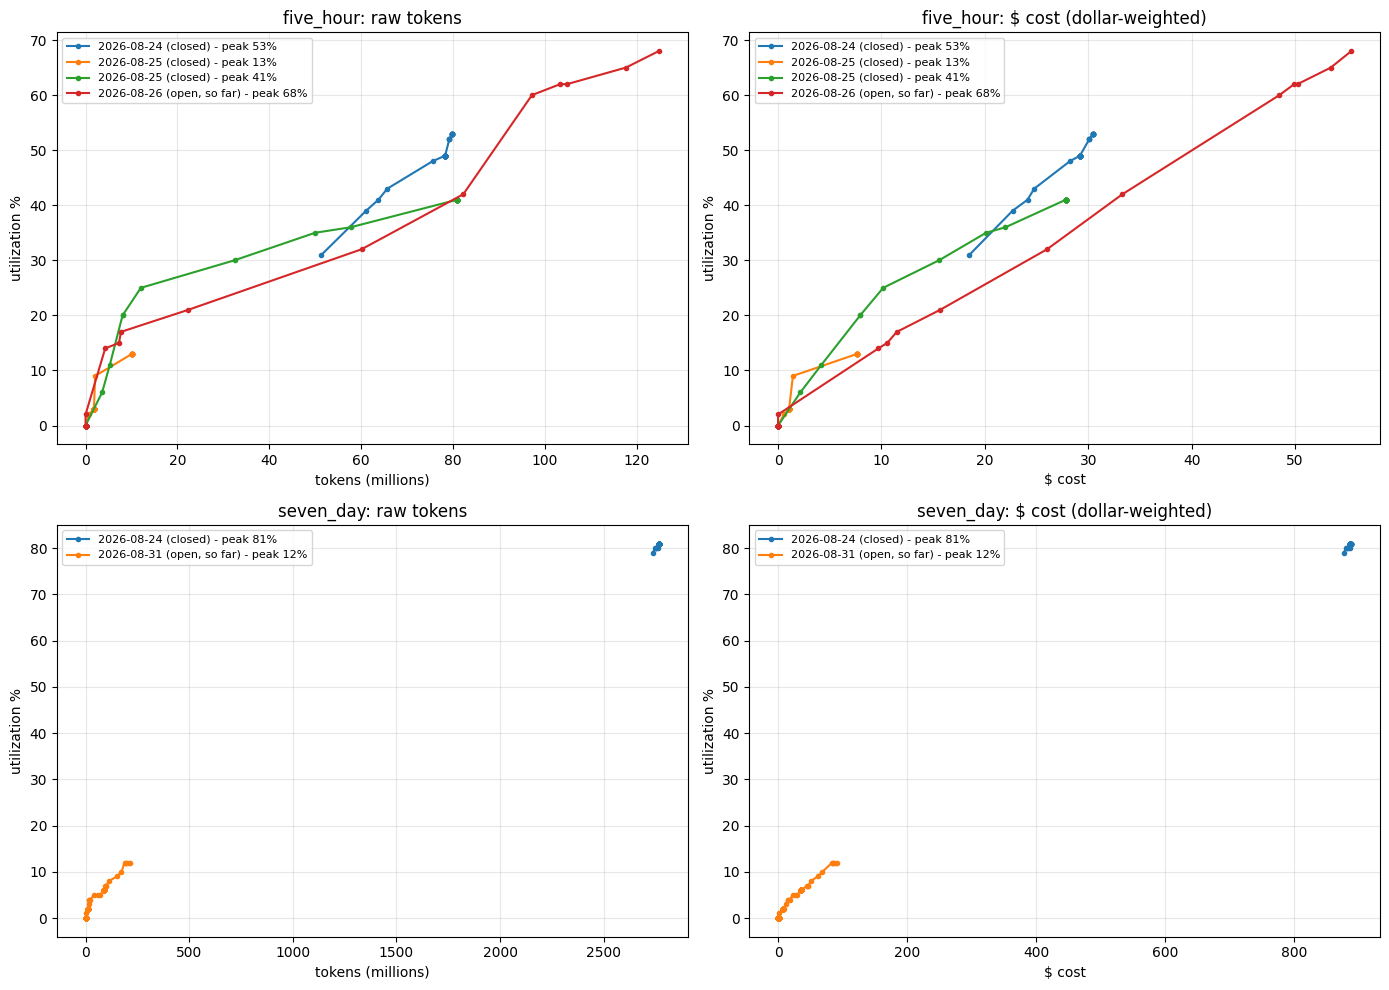

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_windows(axes[0][0], fh_windows, "raw_tokens", "five_hour_pct",
             "five_hour: raw tokens", "tokens (millions)", scale=1e6)
plot_windows(axes[0][1], fh_windows, "dollar_cost", "five_hour_pct",
             "five_hour: $ cost (dollar-weighted)", "$ cost")
plot_windows(axes[1][0], sd_windows, "raw_tokens", "seven_day_pct",
             "seven_day: raw tokens", "tokens (millions)", scale=1e6)
plot_windows(axes[1][1], sd_windows, "dollar_cost", "seven_day_pct",
             "seven_day: $ cost (dollar-weighted)", "$ cost")

fig.tight_layout()
plt.show()

**What to look for**: does each line look straight (linear within a
window)? Do different windows' lines have roughly the same slope (a
stable "budget" - $ or tokens per percentage point) - and is that
slope more consistent in the raw-tokens view or the $-cost view? A
consistent slope across windows in one view but not the other is
evidence for (or against) that view's weighting hypothesis.

## Swapped-axes view

Same data, `SWAP_AXES = True` - X = utilization %, Y = tokens/cost used.
Toggle the `SWAP_AXES` variable near the top of the notebook and re-run
if you'd rather have every plot in this orientation by default.

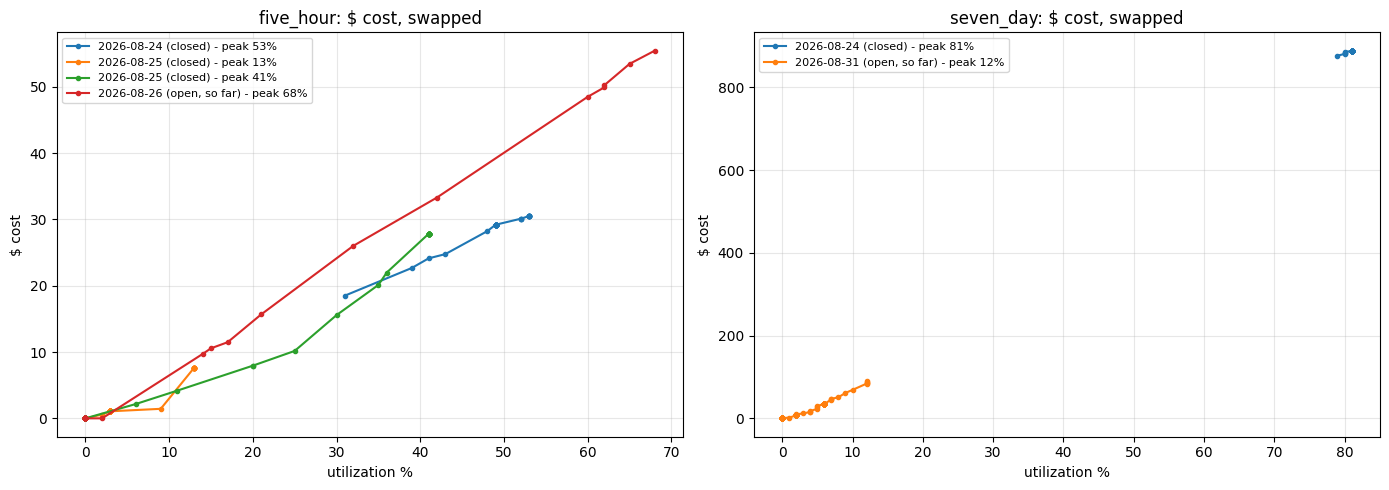

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_windows(axes[0], fh_windows, "dollar_cost", "five_hour_pct",
             "five_hour: $ cost, swapped", "$ cost", swap=True)
plot_windows(axes[1], sd_windows, "dollar_cost", "seven_day_pct",
             "seven_day: $ cost, swapped", "$ cost", swap=True)
fig.tight_layout()
plt.show()